# The final corner plots are at the end

In [96]:
from escripts import edata
from escripts import eMCMC
from escripts import eplots
from matplotlib.gridspec import GridSpec
import math
import emcee
import dataframe_image as dfi
from collections import OrderedDict
import corner
from matplotlib.transforms import Bbox

In [2]:
folder = '/Users/eb35267/Desktop/code/chains/fiducial'
file_name = folder + '/samples.h5'

In [3]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt'
               , '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
params = eMCMC.build_param_data({'beta':{'fit': False, 'value':-1.49}, 'dbetadz':{'fit':False, 'value':0.22}}) #, 'dsigdz':{'fit': False, 'value': 0}})

In [4]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [5]:
# include_params = ['logMc', 'loge', 'dlogedz', 'dsigdz', 'dsigdlogM', 'min_sig']

In [6]:
samples, best_fit, bounds, param_labels, log_prob = my_UVLF.get_fit(backend_file = file_name, return_log_prob=True)

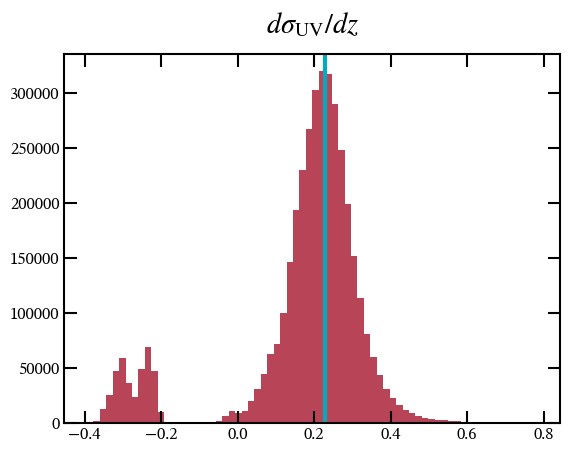

In [7]:
index = -3
fig, ax = plt.subplots()
hist = ax.hist(samples[:,index], bins = 70)
ax.set_title(param_labels[index])
ax.axvline(best_fit[index], color = eplots.turquoise)

In [8]:
selected_idxs = samples[:,index] >-0.1
print(round(len(samples[selected_idxs])/1e6, 2))

3.46


In [9]:
# bin_edges = (hist[1][np.argmax(hist[0])],  hist[1][np.argmax(hist[0])+1])
# np.average(bin_edges)

In [10]:
# walker_fig = eplots.walkers(my_UVLF, best_fit, backend_file = file_name, ncols = 4)

In [11]:
# walker_fig.savefig('/Users/eb35267/Desktop/code/figures/two_fits/walkers.png')

In [12]:
samples_selected = samples[selected_idxs]
samples_not_selected = samples[~selected_idxs]

In [13]:
bounds_selected = np.percentile(samples_selected, [16, 84], axis = 0)
bounds_not_selected = np.percentile(samples_not_selected, [16, 84], axis = 0)

# Before I run the chain all over again for each of these I just want to see what picture the samples I already have paint

In [14]:
bf_selected = samples_selected[np.argmax(log_prob[selected_idxs])]

In [15]:
bf_selected

array([ 5.31465692e-01, -1.05866702e-03,  1.17121973e+01, -5.69082009e-02,
       -1.33758234e+00, -1.13277616e-01,  4.85689221e-01,  2.28790719e-01,
       -1.52199886e-01,  6.78123048e-01])

In [16]:
bf_not_selected = samples_not_selected[np.argmax(log_prob[~selected_idxs])]

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:238: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:238: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)


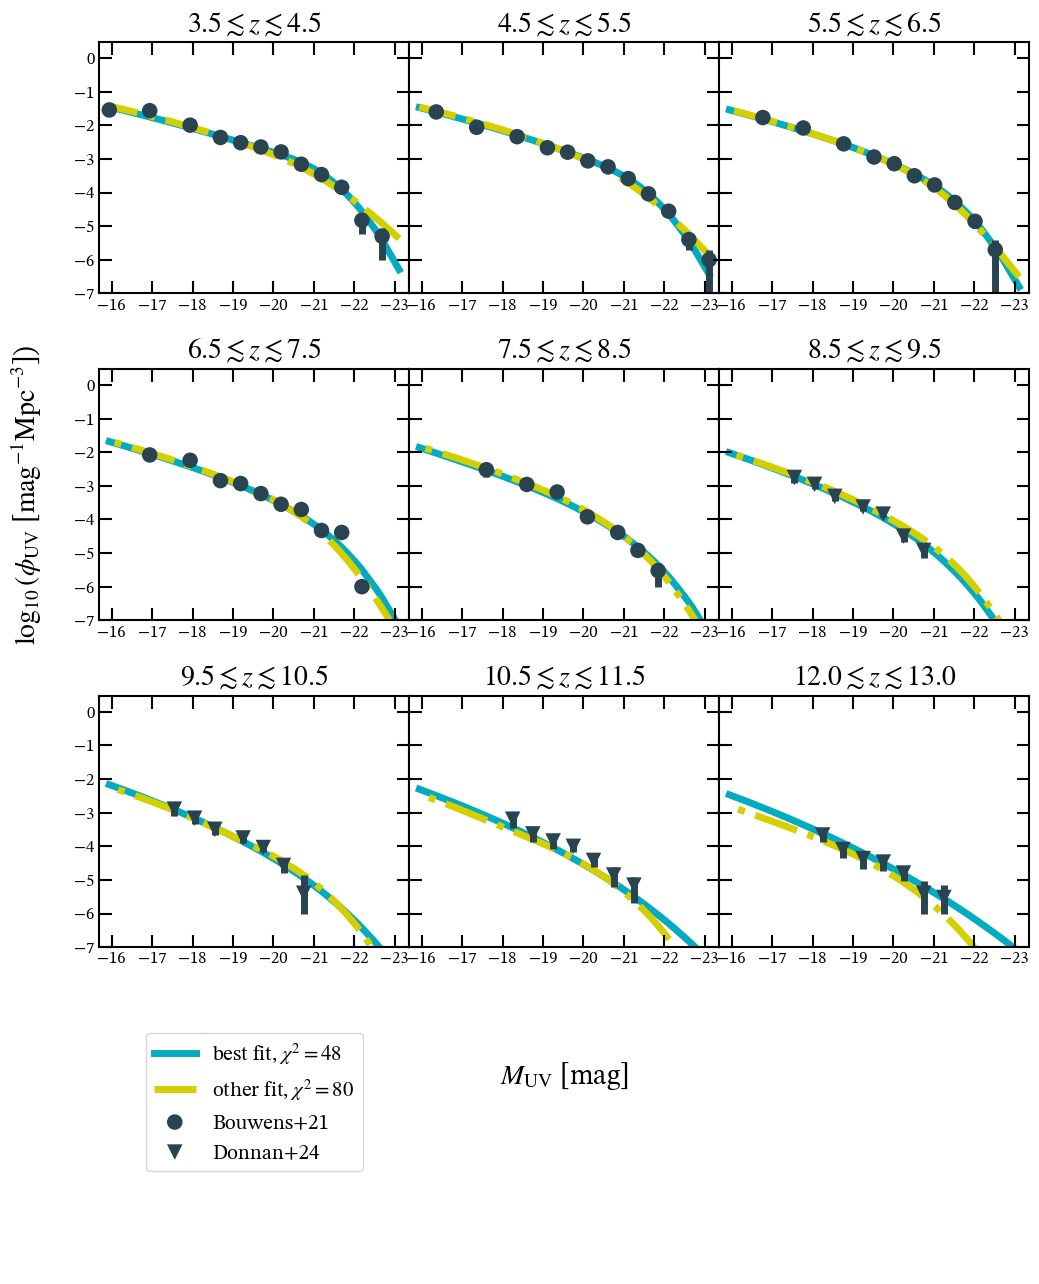

In [17]:
z_plot = [4, 8, 14, 18]
z_err = [0.5, 0.5, 0.5, 2]
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [bf_selected, bf_not_selected], comparison_labels = ['best fit', 'other fit']) #, 
                                  #z_plot = z_plot, z_errs = z_err)

In [18]:
# ev_fig.savefig('/Users/eb35267/Desktop/code/figures/two_fits/UVLF_mode.png')

In [19]:
def compare_fits(samples, fit_labels, best_fits, param_labels, ncols = 3, alpha = 0.5, bounds = None):
    assert(all([len(sample[0]) == len(samples[0][0]) for sample in samples])), 'The samples provided have different numbers of parameters'
    assert(len(param_labels) == len(samples[0][0])), 'The number of parameters doesn\'t match the number of parameters in the sample'
    
    n = len(param_labels)
    fig = plt.figure()
    gs = GridSpec(math.ceil((n+1)/ ncols), ncols, figure=fig)
    plt.subplots_adjust(hspace = 0.5)
    
    axs=[]
    colors = [eplots.turquoise, eplots.yellow]
    for i, label in enumerate(param_labels):
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)
        for sample, color, bf, fit_label in zip(samples, colors, best_fits, fit_labels):
            ax.hist(sample[:,i], alpha=alpha, density = False, label = fit_label, color = color)
            ax.axvline(bf[i], color = color, ls = 'dashed')
            ax.set_title(label)
        if bounds is not None:
            for bound, color in zip(bounds, colors):
                ax.axvline(bound[0][i], color = color, lw = 1,  ls = 'dotted')
                ax.axvline(bound[1][i], color = color, lw = 1,  ls = 'dotted')

    axs[0].plot(best_fits[0][0], 0, ls = 'dashed', color = 'black', label = 'best fit value')
    axs[0].plot(best_fits[0][0], 0, lw = 1, ls = 'dotted', color = 'black', label = 'upper/lower bounds')
    eplots.multicol(gs, axs, include_legend = True)

    return fig

In [20]:
ICs_selected = eMCMC.get_narrowed_ICs(my_UVLF, bf_selected, bounds_selected, labels = param_labels)

In [21]:
ICs_selected

(array([ 0.47764287, -0.02648657, 11.2703519 , -0.13678039, -1.54098409,
        -0.14646714,  0.37116335,  0.1482718 , -0.62782703,  0.61816969]),
 array([ 0.79516539,  0.05134463, 11.83387925, -0.01879421, -1.27405691,
        -0.09973641,  0.72434964,  0.29818675,  0.21004359,  0.86604771]))

In [22]:
ICs_not_selected = eMCMC.get_narrowed_ICs(my_UVLF, bf_not_selected, bounds_not_selected, param_labels)

In [23]:
ICs_not_selected

(array([ 0.74535826,  0.01300326, 11.06074813, -0.21908285, -1.5537143 ,
        -0.06756356,  0.21372331, -0.31841699, -1.06240372,  0.47599017]),
 array([ 1.03895749,  0.04405112, 11.88574364, -0.1595302 , -1.19655993,
         0.01837536,  0.69980171, -0.22635837, -0.58593259,  0.94964298]))

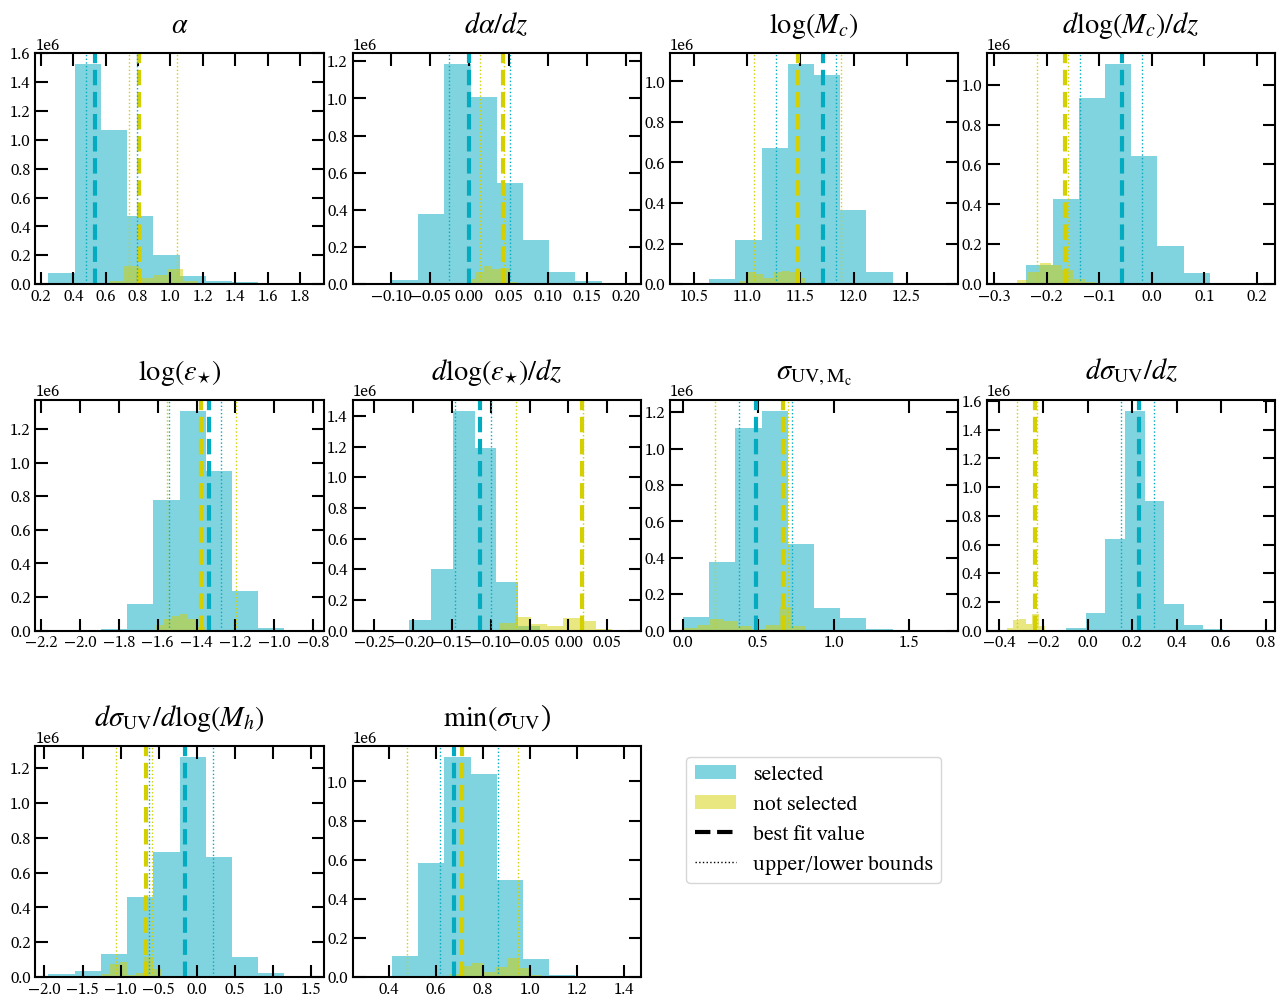

In [24]:
compare_fig = compare_fits([samples_selected, samples_not_selected], ['selected', 'not selected'], [bf_selected, bf_not_selected], param_labels, bounds = [ICs_selected, ICs_not_selected], ncols = 4)

In [25]:
bf_not_selected

array([ 0.80466663,  0.04322691, 11.47324588, -0.16543457, -1.37513712,
        0.017213  ,  0.66640572, -0.23660971, -0.67142162,  0.71281657])

In [26]:
# compare_fig.savefig('/Users/eb35267/Desktop/code/chains/just_HST/two_fits.png')

# Save figures corresponding to new fit

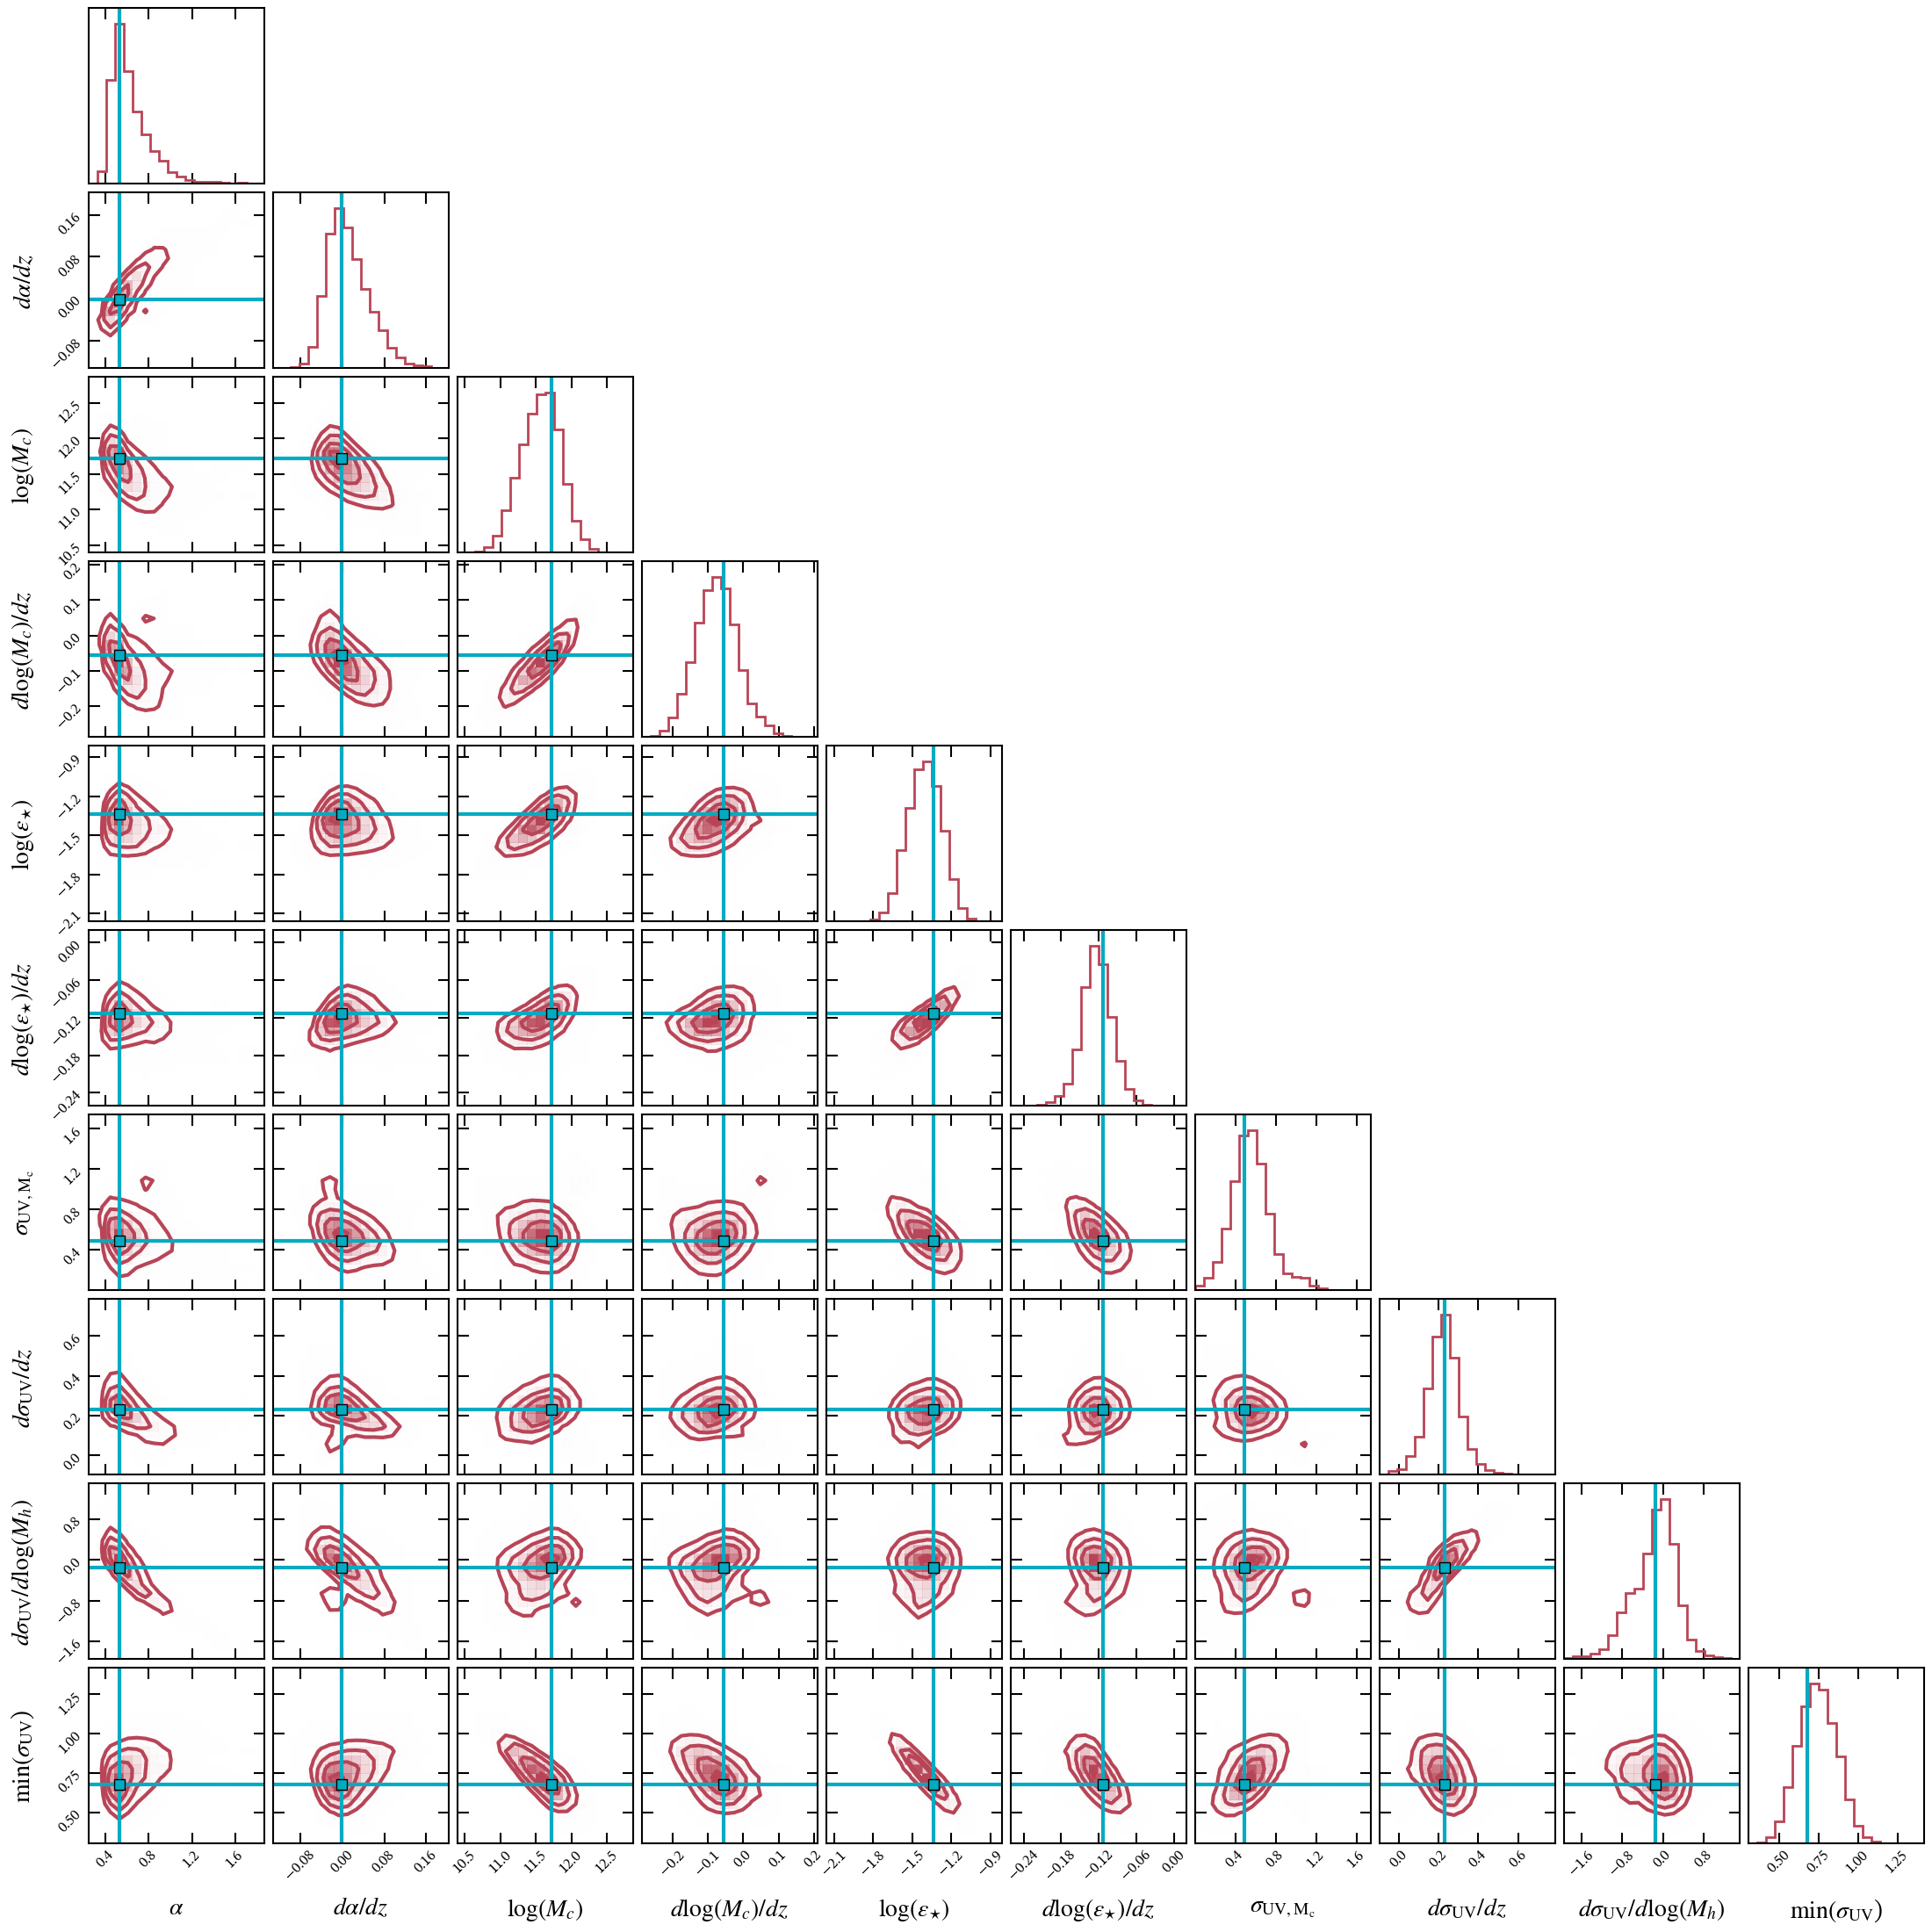

In [27]:
corner = eplots.make_corner(my_UVLF, samples = samples_selected, true_vals = bf_selected)

In [28]:
# corner.savefig(folder + '/corner_narrowed.png')

In [29]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


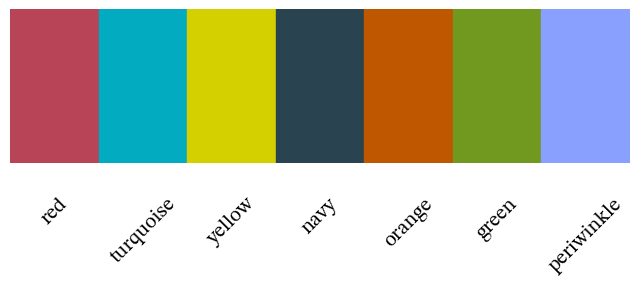

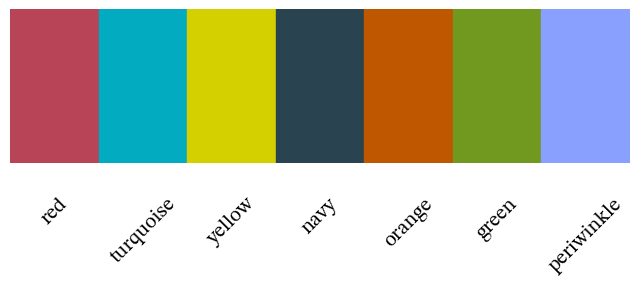

In [30]:
eplots.plot_colors()

In [56]:
isolate_data = np.hstack((samples_selected[:,8].reshape(-1, 1), samples_selected[:,7].reshape(-1, 1)))

In [70]:
fake_data = np.hstack((np.array([-10, -100]).reshape(-1, 1), np.array([-10, -100]).reshape(-1,1)))

In [75]:
my_UVLF.param_data

,fit,value,lower,upper,label
alpha,True,0.6,0,2.5,$\alpha$
dalphadz,True,0,-0.5,0.5,$d\alpha/dz$
beta,False,-1.49,-2,0,$\beta$
dbetadz,False,0.22,-0.5,0.5,$d\beta/dz$
logMc,True,12,10,14,$\log(M_c)$
dlogMcdz,True,0,-0.5,0.5,$d\log(M_c)/dz$
loge,True,-0.5,-3,0,$\log(\epsilon_{\star})$
dlogedz,True,0,-0.5,0.5,$d\log(\epsilon_{\star})/dz$
sig,True,0,0,5,"$\sigma_{\rm{UV}, M_c}$"
dsigdz,True,0,-0.75,1,$d\sigma_{\rm{UV}}/dz$


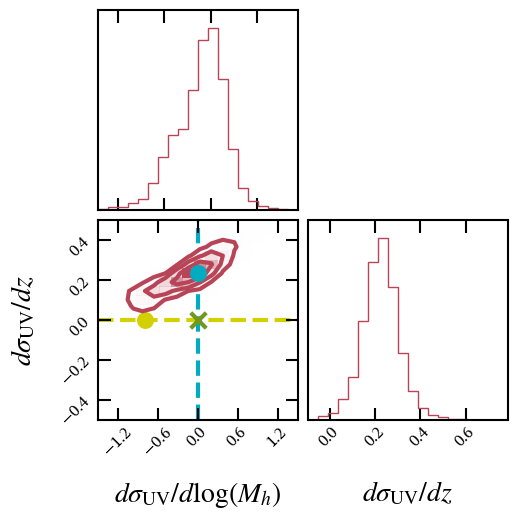

In [184]:
zoomed_corner = corner.corner(isolate_data, plot_contours = True, plot_datapoints = False, color = eplots.red, labels = [r'$d\sigma_{\rm{UV}}/d\log(M_{h})$', r'$d\sigma_{\rm{UV}}/dz$'])


zoomed_corner.axes[2].set_xlim(-1.5, 1.5)
zoomed_corner.axes[2].set_ylim(-0.5, 0.5)

ax2 = zoomed_corner.axes[2]

ax2.scatter(0, 0, marker = 'x', s=125, color = eplots.green)
ax2.axhline(0, color = eplots.yellow, lw = 3, ls = 'dashed', zorder = 0)
ax2.scatter(-0.796, 0, marker = 'o', s=125, color = eplots.yellow)
ax2.axvline(0, color = eplots.turquoise, lw = 3, ls = 'dashed', zorder = 0)
ax2.scatter(0, 0.236, marker = 'o', s=125, color = eplots.turquoise, zorder = 2)

In [185]:
zoomed_corner.savefig('/Users/eb35267/Desktop/figures/Qual_26/Talk/final_corner.png', dpi = 300)

In [110]:
table = eplots.make_table([bf_selected], param_labels, fit_labels = ['best fit'], bounds = [bounds_selected])

In [111]:
table

,best fit
$\alpha$,$0.531^{+0.26}_{-0.05}$
$d\alpha/dz$,$-0.001^{+0.05}_{-0.03}$
$\log(M_c)$,$11.712^{+0.12}_{-0.44}$
$d\log(M_c)/dz$,$-0.057^{+0.04}_{-0.08}$
$\log(\epsilon_{\star})$,$-1.338^{+0.06}_{-0.2}$
$d\log(\epsilon_{\star})/dz$,$-0.113^{+0.01}_{-0.03}$
"$\sigma_{\rm{UV}, M_c}$",$0.486^{+0.24}_{-0.11}$
$d\sigma_{\rm{UV}}/dz$,$0.229^{+0.07}_{-0.08}$
$d\sigma_{\rm{UV}}/d\log(M_{h})$,$-0.152^{+0.36}_{-0.48}$
$\min(\sigma_{\rm{UV}}$),$0.678^{+0.19}_{-0.06}$


In [53]:
dfi.export(table, folder + '/table_narrowed.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)